In [1]:
# Step 1: Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Step 2: Synthetic Dataset Banao
np.random.seed(42)
n_samples = 1000

df = pd.DataFrame({
    'text_length': np.random.randint(50, 500, n_samples),
    'hour_of_submission': np.random.randint(0, 24, n_samples),
    'age': np.random.randint(18, 65, n_samples),
    'budget': np.random.randint(5000, 100000, n_samples),
    'num_adults': np.random.randint(1, 10, n_samples),
    'num_children': np.random.randint(0, 5, n_samples),
    'gender': np.random.choice(['Male', 'Female'], n_samples),
    'location': np.random.choice(['Delhi', 'Mumbai', 'Bangalore', 'Chennai', 'Kolkata'], n_samples),
    'tour_type': np.random.choice(['Adventure', 'Leisure', 'Cultural', 'Beach'], n_samples),
    'converted': np.random.choice([0, 1], n_samples, p=[0.7, 0.3])  # 70% not converted, 30% converted
})

print("✅ Dataset created successfully!")
print("Shape:", df.shape)
print("\nConversion Rate:")
print(df['converted'].value_counts())
df.head()

✅ Dataset created successfully!
Shape: (1000, 10)

Conversion Rate:
converted
0    707
1    293
Name: count, dtype: int64


,text_length,hour_of_submission,age,budget,num_adults,num_children,gender,location,tour_type,converted
0,152,4,24,41751,2,0,Female,Delhi,Cultural,0
1,485,3,20,94822,7,2,Male,Mumbai,Leisure,0
2,398,9,46,10110,3,0,Male,Mumbai,Beach,0
3,320,23,61,59341,8,0,Male,Delhi,Cultural,0
4,156,16,41,17087,7,1,Female,Delhi,Cultural,0


In [3]:
# Step 3: Data Preprocessing
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['location'] = le.fit_transform(df['location'])
df['tour_type'] = le.fit_transform(df['tour_type'])

# Features aur Target
X = df.drop('converted', axis=1)
y = df['converted']

print("✅ Preprocessing done!")
print("Class distribution before SMOTE:")
print(y.value_counts())

✅ Preprocessing done!
Class distribution before SMOTE:
converted
0    707
1    293
Name: count, dtype: int64


In [4]:
# Step 4: SMOTE - Class Imbalance Handle karo
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("✅ SMOTE applied successfully!")
print("Class distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts())

✅ SMOTE applied successfully!
Class distribution after SMOTE:
converted
0    707
1    707
Name: count, dtype: int64


In [5]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Data split successfully!")
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

✅ Data split successfully!
Training size: (1131, 9)
Testing size: (283, 9)


In [6]:
# Step 6: Model Training - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediction
y_pred = rf_model.predict(X_test)

# Evaluation
print("✅ Random Forest Model trained!")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✅ Random Forest Model trained!
Accuracy: 0.6678

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.63      0.67       149
           1       0.63      0.71      0.67       134

    accuracy                           0.67       283
   macro avg       0.67      0.67      0.67       283
weighted avg       0.67      0.67      0.67       283



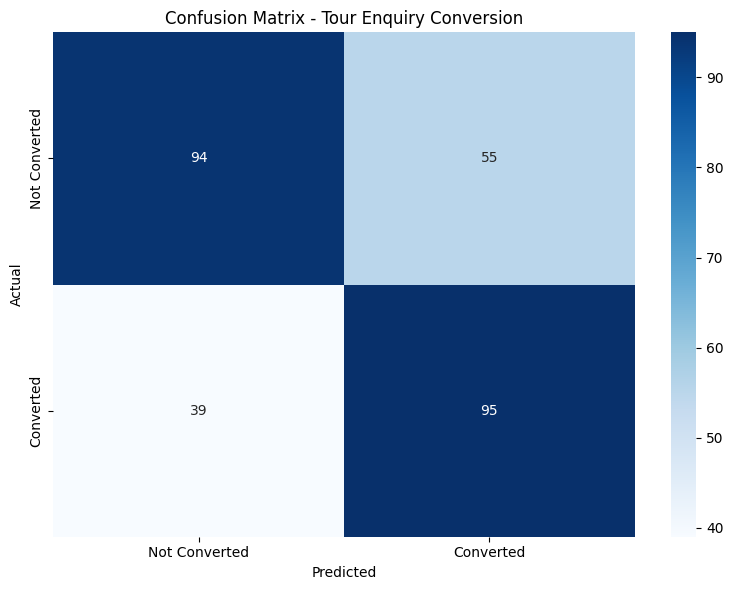

✅ Confusion Matrix saved!


In [7]:
# Step 7: Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'])
plt.title('Confusion Matrix - Tour Enquiry Conversion')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("✅ Confusion Matrix saved!")

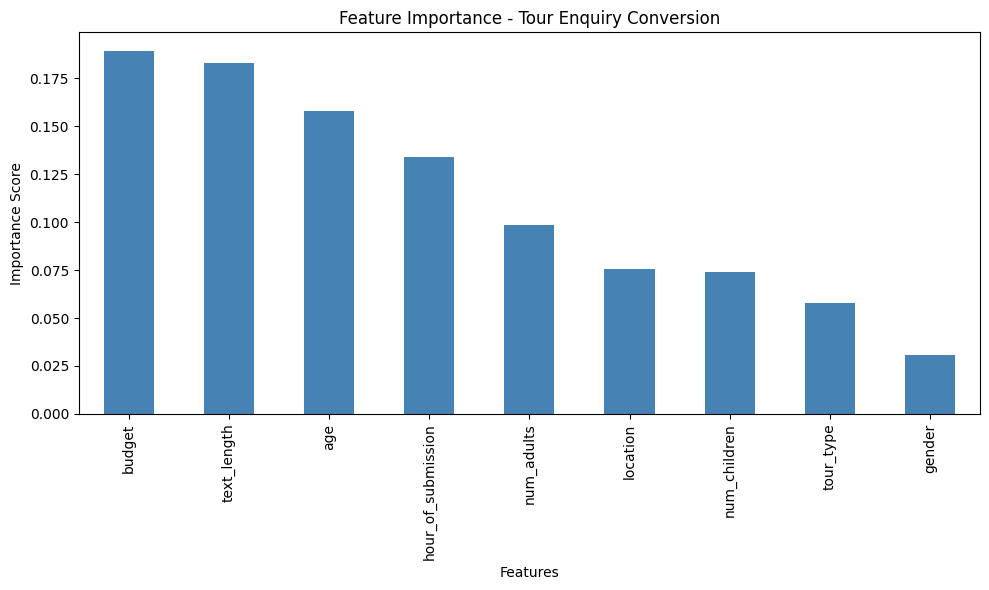

✅ Feature Importance plot saved!


In [8]:
# Step 8: Feature Importance
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Feature Importance - Tour Enquiry Conversion')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("✅ Feature Importance plot saved!")

In [9]:
# Step 9: Model Save karo
import joblib
joblib.dump(rf_model, 'tour_enquiry_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Model saved as tour_enquiry_model.pkl!")

✅ Model saved as tour_enquiry_model.pkl!


In [10]:
# Step 10: Sample Prediction
sample = pd.DataFrame({
    'text_length': [250],
    'hour_of_submission': [10],
    'age': [30],
    'budget': [50000],
    'num_adults': [2],
    'num_children': [1],
    'gender': [1],
    'location': [0],
    'tour_type': [2]
})

sample_scaled = scaler.transform(sample)
prediction = rf_model.predict(sample_scaled)
probability = rf_model.predict_proba(sample_scaled)

print(f"✅ Prediction: {'Converted ✅' if prediction[0] == 1 else 'Not Converted ❌'}")
print(f"Conversion Probability: {probability[0][1]:.2%}")

✅ Prediction: Converted ✅
Conversion Probability: 71.00%
